## Площадь под графиком и управление порогом
### Цель работы
- Научиться применять кривые PR и ROC для оценки моделей классификации, использовать их для выбора оптимального порога классификации

### Содержание работы
- Сгенерируем датасет для бинарной классификации, обучем на нем модель логистической регрессии и построим модели кривые ROC и PR.
- Вычислим для этой модели метрики площади под кривыми (ROC-AUC и PR-AUC).
- Обучим на том же датасете другую модель и сравните ее эффективность по кривым и по метрикам.
- Сгенерируем датасет для бинарной классификации с большим дисбалансом классов, обучим на нам ту же модель и пострим кривые.
- Используя данные, вычисленные для построения кривых для нахождения оптимального значения порога модели.
- Построим матрицу классификации для модели с порогом по умолчанию и с лучшим порогом. Сравним результаты.

In [192]:
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

Начнем с получение датасета для бинарной классификации. Воспользуемся самым простым вариантом - сгенерируем его:

In [194]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)


In [195]:
X.shape, y.shape

((1000, 20), (1000,))

In [196]:
X[:2]

array([[-0.6693561 , -1.49577819, -0.87076638,  1.14183093,  0.02160555,
         1.73062972, -1.25169805,  0.28930464,  0.35716259, -0.19681112,
         0.82927369,  0.15485045, -0.21997009, -0.73913656,  1.80201193,
         1.63460551, -0.93817985, -1.26733697, -1.2763343 ,  1.01664321],
       [ 0.09337237,  0.78584826,  0.10575379,  1.2723535 , -0.84631598,
        -0.97909326,  1.26370668,  0.26402008,  2.41167668, -0.9600463 ,
         0.54347938,  0.19981043,  0.28872366,  0.7324921 , -0.87200205,
        -1.65488744, -1.13020372, -0.12270893,  0.6934308 ,  0.91136272]])

In [198]:
import pandas as pd

df = pd.DataFrame(X)
df['y'] = y
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,y
0,-0.669356,-1.495778,-0.870766,1.141831,0.021606,1.730630,-1.251698,0.289305,0.357163,-0.196811,...,0.154850,-0.219970,-0.739137,1.802012,1.634606,-0.938180,-1.267337,-1.276334,1.016643,1
1,0.093372,0.785848,0.105754,1.272354,-0.846316,-0.979093,1.263707,0.264020,2.411677,-0.960046,...,0.199810,0.288724,0.732492,-0.872002,-1.654887,-1.130204,-0.122709,0.693431,0.911363,0
2,-0.905797,-0.608341,0.295141,0.943716,0.092936,1.370397,-0.064772,0.287273,-0.533004,-0.032504,...,-0.510064,-0.868768,-0.598279,0.019832,0.613460,-1.779439,0.830498,-0.737332,-0.578212,1
3,-0.585793,0.389279,0.698816,0.436236,-0.315082,0.459505,1.448820,0.505558,-1.440982,-1.134020,...,1.466783,0.678728,-1.190917,-1.442381,-0.929136,-0.221600,-0.346772,0.034246,-1.040199,1
4,1.146441,0.515579,-1.222895,-0.396230,-1.293508,-0.352428,0.071254,1.239584,1.007133,-1.479444,...,-0.918127,0.604121,1.068379,-0.882271,2.303639,-0.973379,1.259233,0.360015,1.920368,0


In [199]:
sum(y)

500

In [200]:
df.corr()['y']

0     0.032476
1    -0.507647
2     0.031832
3    -0.005252
4     0.042568
5     0.710614
6    -0.033040
7    -0.014088
8    -0.019103
9     0.004874
10    0.061859
11    0.061596
12   -0.023822
13   -0.023144
14   -0.001696
15   -0.006332
16    0.011239
17    0.017146
18   -0.652179
19    0.023242
y     1.000000
Name: y, dtype: float64

Разделим выборку на обучающую и тестовую. В данном случае нам не очень важны будут показатели эффективности моделей, но важно, чтобы и тестовая и обучающая выборки имели достаточное количество точек. Поэтому поделим датасет пополам, хотя на практике такая пропорция не используется:

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [202]:
model = LogisticRegression().fit(X_train, y_train)

Логистическая регрессия, наряду со многими другими моделями классификации может работать как точечный предиктор (то есть выдавать для входного объекта наиболее вероятный класс), а может - как вероятностный (то есть для данного объекта выдавать оценки вероятности принадлежности к каждому классу, который присутствует в обучающей выборке). Сейчас мы поработаем как раз с этими вероятностями. Получить их очень легко, воспользуемся специальным методом:

In [203]:
import numpy as np
y_pred_proba = model.predict(X_test)
y_pred_proba[:10]

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0])

In [204]:
import numpy as np
y_pred_proba = model.predict_proba(X_test)
y_pred_proba[:10]

array([[0.55658418, 0.44341582],
       [0.07720666, 0.92279334],
       [0.51233333, 0.48766667],
       [0.18372582, 0.81627418],
       [0.03573181, 0.96426819],
       [0.91660508, 0.08339492],
       [0.69440462, 0.30559538],
       [0.25478708, 0.74521292],
       [0.27907146, 0.72092854],
       [0.68905431, 0.31094569]])

<img src="source/2.png" width="600px" />

<img src="source/1.png" width="600px" />

Мы получили матрицу вероятностей:

В этой матрице количество строк совпадает с количеством объектов, которые мы передали методу (в данном случае мы передали всю тестовую выборку). Для каждого объекта в матрице указано два значения - вероятности его отнесения, по мнению модели, соответственно, к отрицательному и положительному классу. Так как задача у нас бинарная, можно заметить, что эти два числа всегда дают в сумме единицу. В общем случае, для множественной классификации, это не обязательно выполняется. Но в данном случае нам дальше вообще понадобится только второй столбец этой матрицы.

Для построения кривой ROC используем встроенную в sklearn функцию roc_curve, которая находится в пакете metrics:

In [210]:
y_test[:5]

array([1, 1, 1, 1, 1])

In [209]:
 y_pred_proba[:, 1][:5]

array([0.44341582, 0.92279334, 0.48766667, 0.81627418, 0.96426819])

In [205]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])


Данная функция возвражает три массива: значения метрики FPR (false positive rate), TPR (true positive rate) и значение порога. Фактически, данная функция берет определенное количество значений порога (в промежутке от 0 до 1), применяет данный порог для точной классификации, исходя из переданной ей матрицы вероятностей, и вычисляет при данном значении порога две упомянутые метрики.

Значения порога нас пока не очень интересуют, а первые два массива мы используем для построения графика - того самомго ROC:

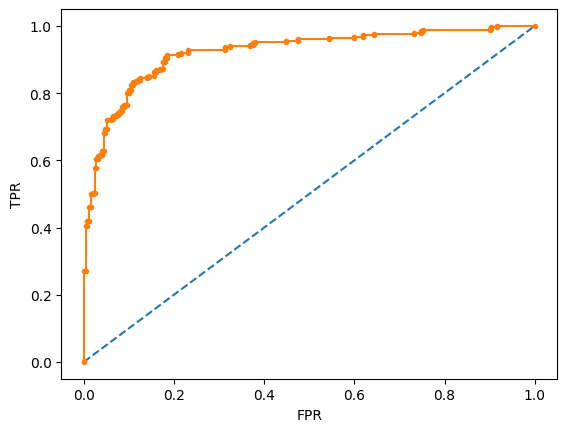

In [213]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.xlabel("FPR")        # label for the x-axis
plt.ylabel("TPR")
plt.show()

прямая между точками (0,0) и (1, 1) - это референсная линия

Из графика мы видим, что кривая находится выше прямой, что свидетельствует о том, что классификатор работает лучше, чем случайное предсказание. Но можно заметить, что при разных значениях порога (зеленые точки на графике) модель имеет значительно различающиеся характеристики. И только одна точка на этом графике характеризует поведение модели при "дефолтном" значении порога - то, что мы обычно не задумываясь получаем методом predict.

Но анализ графика может нам дать только примерное представление о том, насколько хороша модель. Особенно сейчас, когда нам не с чем ее сравнить. Боле четкую оценку даст метрика ROC-AUC, измеряющая площадь под графиком данной кривой. Эту метрику также легко получить:

In [214]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

roc_auc_score(y_test, y_pred_proba[:, 1])

0.922416

В данном случае, мы имеем значение примерно в 90%, что можно интерпретировать как общее качество модели вне зависимости от выбранного порога.

Давайте по аналогии построим график PR-кривой. Из лекции мы знаем, что он строится по аналогичному признаку, но в других координатах. Конечно, библиотека sklearn и здесь позволяет пользоваться готовыми функциями:

In [215]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
precision[:3], recall[:3]

(array([0.5       , 0.501002  , 0.50200803]), array([1., 1., 1.]))

Обратите внимание, что в этих координатах (precision и recall) эффективность тривиального классификатора уже не так примитивна и ависит от соотношения классов в обучающей выборке. можно его изобразить:

А теперь можно вывести на график и саму кривую PR:

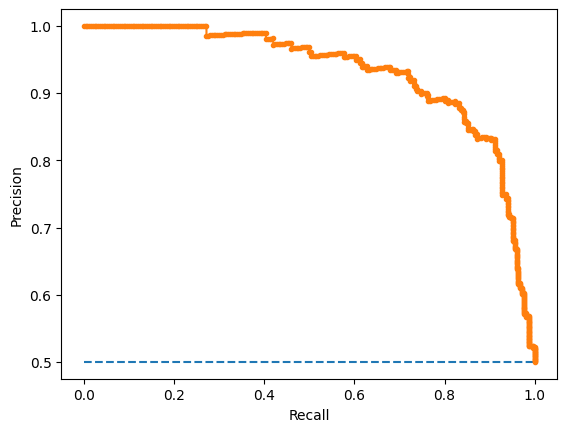

In [217]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")        # label for the x-axis
plt.ylabel("Precision")
plt.show()

Эта метрика численно чуть ниже - порядка 89,8%. Еще это число называют средней точностью модели - average precision.

Полезно посмотреть, как полученные данные соотносятся с уже знакомыми нам характеристиками классификации. Давайте построим отчет о классификации по данной модели:

In [218]:
from sklearn.metrics import classification_report 

y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       250
           1       0.88      0.82      0.85       250

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500



Важно понимать, что данный отчет характеризует поведение модели только в одной точке - при значении порога, равном по умолчанию 0,5. Кривые же показывают, как модель будет работать при все возможных значениях порога.

Давайте для сравнения попробуем обучить на этих же данных другую модель. Например, метод ближайших сосдей. Вы можете выбрать любую другую модель (но обратите внимание, что не все модели имеют метод redict_proba, а нам он обязательно понадоится. Почему так, читайте в документации к моделям):

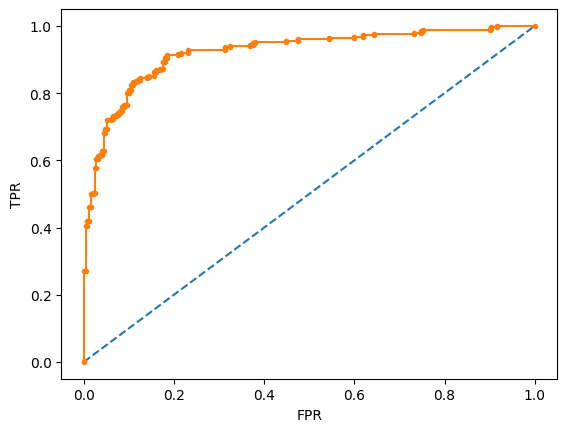

In [230]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr_n, tpr_n, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.xlabel("FPR")        # label for the x-axis
plt.ylabel("TPR")
plt.show()

In [231]:
y_pred2_proba[:2]

array([[0.4, 0.6],
       [0.4, 0.6]])

График будет выглядеть чуть по-другому, но в целом похоже на ROC первой модели. Поэтому для точного сравнения более полезны численные метрики:

In [232]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.875288

Тут явно видно, что ROC-AUC второй модели значимо хуже - 86,3%.

### Диcбаланс классов
Наиболее явно различия между этими двумя классификационными кривыми - ROC и PR - демонстрирует пример с большим дизбалансом классов. Давайте сгенерируем датасет, в котором объектов разных классов не примерно равное количество, как в предыдущем примере, а объектов отрицательного класса, скажем, 99%. Для этого очень удобно воспользоваться атрибутом weights функции make_classification:

In [238]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=42)

In [239]:
y.sum()

13

Также разделим эту выборку на две части. Но сдесь надо быть аккуратными, поэтому сразу выведем объем классов в получившихся частях:

In [240]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=987, Class1=13
Обучающая: Class0=493, Class1=7
Тестовая: Class0=494, Class1=6


Видно, что в одной половине выборки положительных объектов в два раза больше, чем в другой. При случайном разделении, если есть сильно миноритарные классы, может случиться и не такое. Например, мы можем случайно получить выборку, в которой какие-то классы не представлены вообще. Для предотвращения таких случаев нужно воспользоваться стратификацией:

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=987, Class1=13
Обучающая: Class0=494, Class1=6
Тестовая: Class0=493, Class1=7


Распределение уже гораздо более равномерное. Для стратификации можно задавать любой массив, не обязательно значение целевой переменной, и разделение произойдет так, чтобы созранить распределение, заданное в этом массиве. Но целевую переменную здесь используют чаще всего.

Точно также, как и в предыдущем примере, обучим модель и сразу вычислим матрицу вероятностей:

In [244]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred_proba[:10]

array([[9.97130402e-01, 2.86959838e-03],
       [9.93256672e-01, 6.74332843e-03],
       [9.99882930e-01, 1.17069526e-04],
       [9.92901998e-01, 7.09800198e-03],
       [9.99057115e-01, 9.42885320e-04],
       [9.99880861e-01, 1.19139102e-04],
       [9.99639328e-01, 3.60671870e-04],
       [9.89019689e-01, 1.09803113e-02],
       [9.62760742e-01, 3.72392582e-02],
       [9.99989868e-01, 1.01318628e-05]])

In [247]:
y_pred_proba[:,1].max()

0.8368174878214357

Сразу познакомимся с дефолтным поведением модели, построив отчет о классификации:

In [245]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       493
           1       1.00      0.14      0.25         7

    accuracy                           0.99       500
   macro avg       0.99      0.57      0.62       500
weighted avg       0.99      0.99      0.98       500



Здесь мы видим классическую картину обучения на неравномерной выборке. Мажоритарный класс (в данном случае - отрицательный, он у нас в большинстве) распознается очень хорошо, а миноритарный - очень плохо. В нашем случае, вообще по положительному классу все метрики нулевые. Но обратите внимание, что общая (accuracy) модели весьма приемлема - 98%. Диcбаланс классов "скрывает" в точности недостатки работы модели.

Построим ROC данной модели:

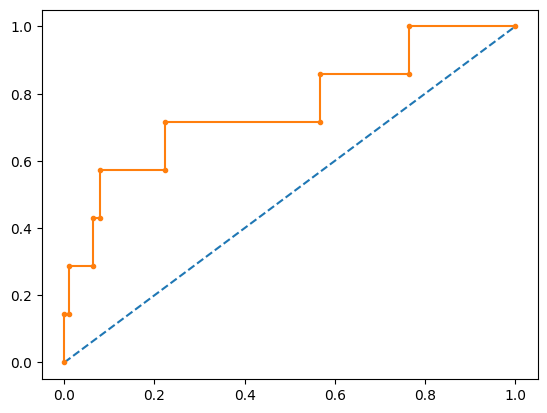

In [248]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

Мы видим. что вривая показывает не идеальное, но вполне примелемое поведение модели. Средняя точность будет, несомненно, ниже, чем в первом примере работы, но ничего катастрофического мы здесь не наблюдаем. Но давайте построим кривую PR:

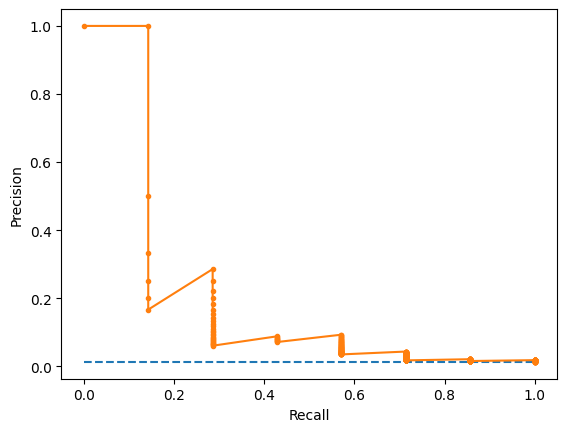

In [250]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")        # label for the x-axis
plt.ylabel("Precision")
plt.show()

И вот на этом графике уже открывается истинное поведение модели: она не очень-то отличается от тривиальной, просто чаще предсказывает самый распространенный класс. Так как метрики Precision и Recall специально были созданы для случая несбалансированных классов, именно PR-кривая дает более реалистические оценки эффективности работы моделей классификации на таких данных, где наблюдается большой дисбаланс классов.

### Выбор значения порога по кривым
Кривые классификации, несомненно, удобный и визуальный способ представления эффективности работы моделей машинного обучения. Но главная их ценность состоит в том, что данные, которые необходимы для их построения могут использоваться для оптимизации порога классификации. Мы уже поняли, что разные значения порога могут приводить к разному поведению моделей и, как следствие, к имзенению метрик. Значит, можно выбрать такой порог, который дает более точную классификацию?

Да, но для этого нам понадобится некоторый критерий - численное значение, которые мы хотим оптимизировать. В лекции мы уже говорили, что простые метрики - precision, recall, accuracy - не очень подходят на роль критерия оптимизации. Но мы можем использовать, например, метрику F1 (и любые метрики из F-семейства). Для этого еще раз сгенерируем датасет, сделаем чуть больше объем данных:

In [255]:
X, y = make_classification(n_samples=10_000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Изобразим PR-кривую:

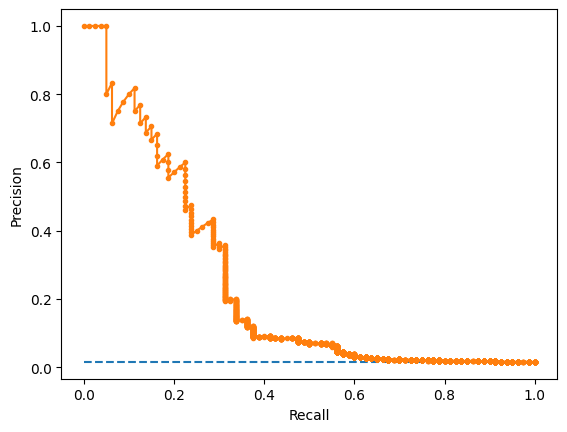

In [257]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.xlabel("Recall")        # label for the x-axis
plt.ylabel("Precision")
plt.show()

In [272]:
import pandas as pd
d = pd.DataFrame({'pr': p[:5000], 'rec': r[:5000], 'th': pr_thresholds})
d.tail(20)

,pr,rec,th
4980,0.650000,0.1625,0.538918
4981,0.684211,0.1625,0.565335
4982,0.666667,0.1500,0.565796
4983,0.705882,0.1500,0.575384
4984,0.687500,0.1375,0.590861
4985,0.733333,0.1375,0.609704
4986,0.714286,0.1250,0.637309
4987,0.769231,0.1250,0.639619
4988,0.750000,0.1125,0.681513
4989,0.818182,0.1125,0.704919


По точкам на ней мы видим, что при разных значениях порога иногда метрика precision будет больше, иногда - recall. Именно поэтому мы будем оптимизировать по метрике F1. Для этого импортируем из бибилиотеки numpy функцию argmax:

In [258]:
from numpy import argmax

Вычислим вектор метрик F1 при всех использованных значениях порога и найдем самое большое значение среди них (вернее, его индекс):

In [273]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
pr_thresholds[ix]

0.18762960077838223

In [274]:
ix

4947

In [ ]:
pr_thresholds

Так как индексы всех массивов, возвращенных функцией precision_recall_curve соответственны, по этому индексу получим значение порога и соответствующее ему значение метрики F1:

In [275]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.187630, F-Score=0.346


Теперь мы можем изобразить эту точку на графике самой кривой:

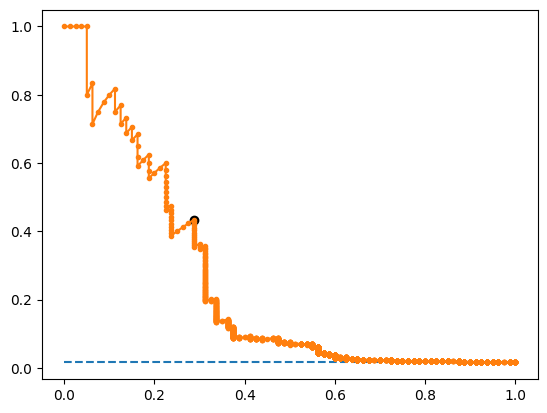

In [276]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.show()

Обратите внимание, что мы использовали метрику F1 - это среднее геометрическое между Precision и Recall. При этом эти две метрики имеют равный вклад в среднее. Бывают ситуации, когда нам более приоритетна одна из этих двух метрик. Тогда следует использоваться параметрическую метрику из F-семейства. Мы можем придать в среднем разный вес, то есть больше предпочесть recall или, наоборот, precision.

Давайте используем данное значение порога для проведение непосредственной классификации. Раньше мы так не делали, так как всегда использовали метод predict, который всегда использует порог по умолчанию - 0,5. Но точечная классификация - это не что иное, как выбор положительного класса, если модель оценивает вероятность принадлежности к нему выше порога:

In [277]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')

Полученный вектор значений можно использовать при построении точета о классфикации:

In [278]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4920
           1       0.42      0.28      0.33        80

    accuracy                           0.98      5000
   macro avg       0.71      0.63      0.66      5000
weighted avg       0.98      0.98      0.98      5000



А вот для сравнения, отчет о классификации для той же модели, но при использованиии порога по умолчанию:

In [279]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.62      0.16      0.26        80

    accuracy                           0.98      5000
   macro avg       0.80      0.58      0.62      5000
weighted avg       0.98      0.98      0.98      5000

